In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TARGET = "recovery_rate"
pd.set_option("display.width", 120)

In [ ]:
try:
    from google.colab import files
    uploaded = files.upload()  # select both CSVs;
except ImportError:
    pass  # not running on Colab

In [ ]:
train_df = pd.read_csv("arc_loan_recovery_train.csv")
test_df = pd.read_csv("arc_loan_recovery_test.csv")
print("train:", train_df.shape, " test:", test_df.shape)
train_df.head()

train: (7000, 32)  test: (2000, 28)


,loan_id,loan_amount,term_months,grade,sub_grade,int_rate,emp_length_years,home_ownership,annual_income,verification_status,...,collateral_value,total_pymnt_before_default,outstanding_principal,days_past_due_at_default,months_in_recovery,recovery_status,payment_plan_status,recoveries,collection_recovery_fee,recovery_rate
0,ARC100186,10900.0,60,E,E2,21.98,1.0,RENT,95500.0,Source Verified,...,NaN,4473.43,6426.57,72,23,Closed,No_Plan,800.75,103.09,0.1246
1,ARC106212,17100.0,36,B,B5,10.87,10.0,MORTGAGE,36700.0,Not Verified,...,NaN,8634.50,8465.50,75,8,Closed,Active,4810.94,563.55,0.5683
2,ARC101863,17400.0,36,G,G3,28.82,10.0,RENT,50100.0,Source Verified,...,NaN,5100.21,12299.79,32,32,Closed,Broken,3624.75,366.76,0.2947
3,ARC100317,6700.0,36,A,A1,10.62,9.0,MORTGAGE,20400.0,Not Verified,...,NaN,1525.02,5174.98,108,30,Closed,Active,2387.22,305.99,0.4613
4,ARC106446,24200.0,60,B,B4,10.44,NaN,RENT,45200.0,Source Verified,...,13800.0,4413.43,19786.57,292,20,Closed,Active,9606.38,594.96,0.4855


In [ ]:
print("Missing values (train):")
print(train_df.isna().sum()[train_df.isna().sum() > 0])
print()
print("recovery_rate summary:")
print(train_df["recovery_rate"].describe())

Missing values (train):
emp_length_years     346
annual_income        494
dti                  205
revol_util           279
collateral_value    5444
dtype: int64

recovery_rate summary:
count    7000.000000
mean        0.415695
std         0.191917
min         0.021400
25%         0.266400
50%         0.406850
75%         0.559200
max         0.959800
Name: recovery_rate, dtype: float64


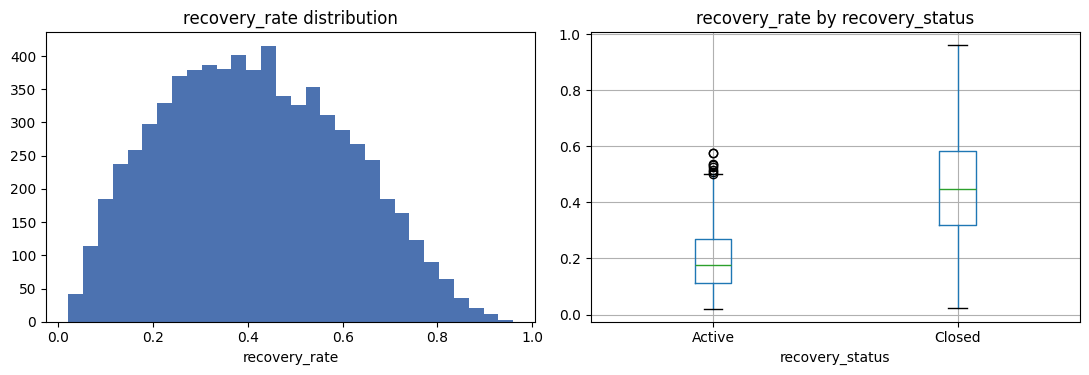

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_df["recovery_rate"], bins=30, color="#4C72B0")
axes[0].set_title("recovery_rate distribution")
axes[0].set_xlabel("recovery_rate")

train_df.boxplot(column="recovery_rate", by="recovery_status", ax=axes[1])
axes[1].set_title("recovery_rate by recovery_status")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
implied = (train_df["recoveries"] / train_df["outstanding_principal"]).clip(0, 1)
print("max gap vs recovery_rate:", (implied - train_df["recovery_rate"]).abs().max())

print("payment_plan_status in test columns:", "payment_plan_status" in test_df.columns)
print("dti == -999 rows:", (train_df["dti"] == -999).sum())
print("collateral_value NaN matches collateral_flag==0:",
      (train_df["collateral_value"].isna() == (train_df["collateral_flag"] == 0)).all())
print("fico gap values:", (train_df["fico_range_high"] - train_df["fico_range_low"]).unique())

max gap vs recovery_rate: 5.023063906706149e-06
payment_plan_status in test columns: False
dti == -999 rows: 73
collateral_value NaN matches collateral_flag==0: True
fico gap values: [4]


##  Clean and engineer features



In [ ]:
def clean(df: pd.DataFrame) -> pd.DataFrame:
    '''Fix known data-quality issues; changes representation, not meaning.'''
    df = df.copy()
    df["home_ownership"] = df["home_ownership"].str.upper()
    df["dti"] = df["dti"].replace(-999, np.nan)
    df["collateral_value"] = df["collateral_value"].fillna(0.0)
    return df

In [ ]:
LOG_MONEY_COLS = [
    "loan_amount", "annual_income", "revol_bal",
    "collateral_value", "total_pymnt_before_default", "outstanding_principal",
]
MISSING_FLAG_COLS = ["dti", "annual_income", "revol_util", "emp_length_years"]


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    '''Derive model-ready features. Never touches recoveries / collection_recovery_fee / recovery_rate.'''
    df = df.copy()

    for col in MISSING_FLAG_COLS:
        df[f"{col}_is_missing"] = df[col].isna().astype(int)

    for col in LOG_MONEY_COLS:
        df[f"log_{col}"] = np.log1p(df[col])

    df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
    df["pct_paid_before_default"] = df["total_pymnt_before_default"] / df["loan_amount"]
    df["principal_remaining_pct"] = df["outstanding_principal"] / df["loan_amount"]
    df["loan_to_income"] = df["loan_amount"] / df["annual_income"]
    df["collateral_coverage"] = np.where(
        df["collateral_flag"] == 1,
        df["collateral_value"] / df["outstanding_principal"],
        0.0,
    )
    return df


train_fe = engineer_features(clean(train_df))
test_fe = engineer_features(clean(test_df))

In [ ]:
NUMERIC_FEATURES = [
    "log_loan_amount", "term_months", "int_rate", "emp_length_years",
    "log_annual_income", "dti", "fico_avg", "delinq_2yrs", "pub_rec",
    "open_acc", "total_acc", "log_revol_bal", "revol_util",
    "collections_12_mths_ex_med", "collateral_flag", "log_collateral_value",
    "collateral_coverage", "log_total_pymnt_before_default",
    "log_outstanding_principal", "pct_paid_before_default",
    "principal_remaining_pct", "loan_to_income", "days_past_due_at_default",
    "months_in_recovery",
] + [f"{c}_is_missing" for c in MISSING_FLAG_COLS]

CATEGORICAL_FEATURES = ["sub_grade", "home_ownership", "verification_status", "purpose", "recovery_status"]

FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
assert set(FEATURE_COLS).issubset(test_fe.columns), "a chosen feature isn't available in the test file"
print(f"{len(FEATURE_COLS)} features: {len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical")

33 features: 28 numeric + 5 categorical


## Train / validation split



In [ ]:
X = train_fe[FEATURE_COLS]
y = train_fe[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=train_fe["recovery_status"],
)
print(f"train: {X_train.shape[0]} rows, val: {X_val.shape[0]} rows")

train: 5600 rows, val: 1400 rows


## Preprocessing + candidate models


In [ ]:
def build_preprocessor() -> ColumnTransformer:
    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, NUMERIC_FEATURES),
        ("cat", categorical_pipe, CATEGORICAL_FEATURES),
    ])


def build_candidate_models() -> dict:
    return {
        "baseline_mean": DummyRegressor(strategy="mean"),
        "ridge": RidgeCV(alphas=np.logspace(-2, 3, 20)),
        "random_forest": RandomForestRegressor(
            n_estimators=300, max_depth=8, min_samples_leaf=5,
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
        "hist_gradient_boosting": HistGradientBoostingRegressor(
            max_depth=3, learning_rate=0.05, max_iter=300, random_state=RANDOM_STATE,
        ),
    }

##  Compare models with 5-fold cross-validation (on the training split only)

In [ ]:
def cross_validate_models(models: dict, X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"}
    rows = []
    for name, model in models.items():
        pipe = Pipeline([("prep", build_preprocessor()), ("model", model)])
        scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        rows.append({
            "model": name,
            "r2_mean": scores["test_r2"].mean(),
            "r2_std": scores["test_r2"].std(),
            "mae_mean": -scores["test_mae"].mean(),
            "rmse_mean": -scores["test_rmse"].mean(),
        })
    return pd.DataFrame(rows).sort_values("r2_mean", ascending=False).reset_index(drop=True)


cv_results = cross_validate_models(build_candidate_models(), X_train, y_train)
cv_results

,model,r2_mean,r2_std,mae_mean,rmse_mean
0,hist_gradient_boosting,0.610436,0.011171,0.097111,0.120669
1,ridge,0.602596,0.010098,0.098508,0.121878
2,random_forest,0.572209,0.009513,0.102155,0.126449
3,baseline_mean,-0.000732,0.000899,0.161684,0.193429


##Held-out validation — the one honest check


In [ ]:
val_preds = np.clip(best_pipe.predict(X_val), 0, 1)

print(f"R²:   {r2_score(y_val, val_preds):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, val_preds):.4f}")
print(f"RMSE: {mean_squared_error(y_val, val_preds) ** 0.5:.4f}")

R²:   0.6150
MAE:  0.0937
RMSE: 0.1152


## Calibration



        mean_pred  mean_actual    n
decile                             
0           0.159        0.175  140
1           0.246        0.255  140
2           0.311        0.309  140
3           0.368        0.369  140
4           0.412        0.394  140
5           0.449        0.433  140
6           0.486        0.482  140
7           0.523        0.535  140
8           0.569        0.572  140
9           0.656        0.674  140


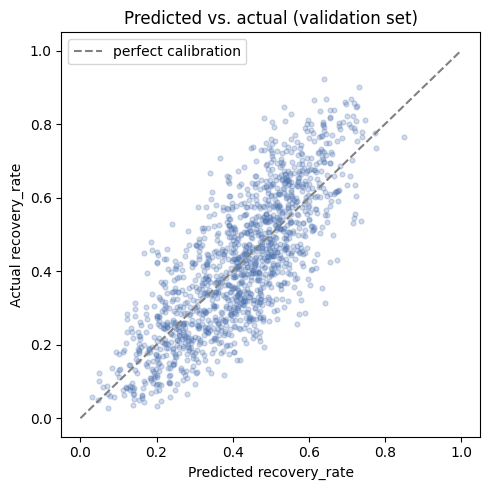

In [ ]:
calib = pd.DataFrame({"actual": y_val.values, "pred": val_preds})
calib["decile"] = pd.qcut(calib["pred"], 10, labels=False, duplicates="drop")
calib_summary = calib.groupby("decile").agg(
    mean_pred=("pred", "mean"), mean_actual=("actual", "mean"), n=("actual", "size"),
)
print(calib_summary.round(3))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(calib["pred"], calib["actual"], alpha=0.25, s=12, color="#4C72B0")
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
ax.set_xlabel("Predicted recovery_rate")
ax.set_ylabel("Actual recovery_rate")
ax.set_title("Predicted vs. actual (validation set)")
ax.legend()
plt.tight_layout()
plt.show()

##  What's driving the predictions


                 feature  importance
         recovery_status    0.464402
                fico_avg    0.351858
days_past_due_at_default    0.111775
                     dti    0.077886
             delinq_2yrs    0.039156
         collateral_flag    0.028065
     collateral_coverage    0.022632
        emp_length_years    0.021051
                 pub_rec    0.017410
          loan_to_income    0.011715


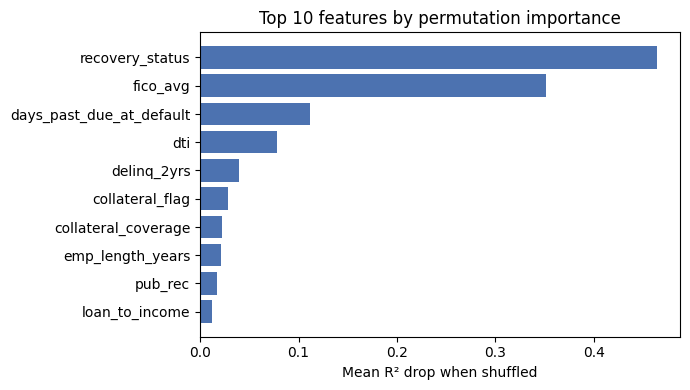

In [ ]:
perm = permutation_importance(
    best_pipe, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, scoring="r2", n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS, "importance": perm.importances_mean,
}).sort_values("importance", ascending=False).head(10)
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="#4C72B0")
ax.set_xlabel("Mean R² drop when shuffled")
ax.set_title("Top 10 features by permutation importance")
plt.tight_layout()
plt.show()

## Refit on all labeled data and predict on the test set



In [ ]:
final_pipe = Pipeline([("prep", build_preprocessor()), ("model", build_candidate_models()[best_name])])
final_pipe.fit(X, y)

raw_test_preds = final_pipe.predict(test_fe[FEATURE_COLS])
print(f"raw predictions outside [0, 1]: {((raw_test_preds < 0) | (raw_test_preds > 1)).sum()} / {len(raw_test_preds)}")
test_preds = np.clip(raw_test_preds, 0, 1)

submission = pd.DataFrame({
    "loan_id": test_fe["loan_id"],
    "predicted_recovery_rate": test_preds,
})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

raw predictions outside [0, 1]: 3 / 2000
(2000, 2)


,loan_id,predicted_recovery_rate
0,ARC104645,0.562043
1,ARC104205,0.531759
2,ARC102896,0.143596
3,ARC106617,0.237879
4,ARC105889,0.170889


In [ ]:
try:
    files.download("submission.csv")
except NameError:
    pass  # not running on Colab,find submission.csv in the working directory instead